In [1]:
import sys
import os

# Fix the path so Python can find your project files
os.chdir("..")
sys.path.append(".")

from feature_store.feature_store import FeatureStore
import pandas as pd

fs = FeatureStore()
print("FeatureStore ready!")

FeatureStore connected to feature_store/localpulse.db
FeatureStore ready!


In [2]:
# See what cities and features we have
fs.get_all_cities()
fs.list_features()


Available cities: ['New York', 'Austin', 'Chicago', 'Miami', 'Seattle']

Registered Features:
          feature_name  version                         description     source_table          created_at
              avg_temp        1         Average of max and min temp weather_features 2026-05-15 14:16:07
            temp_range        1 Difference between max and min temp weather_features 2026-05-15 14:16:07
precipitation_category        1 Wet / moderate / dry classification weather_features 2026-05-15 14:16:07
         temp_category        1      Hot / warm / mild / cold label weather_features 2026-05-15 14:16:07


,feature_name,version,description,source_table,created_at
0,avg_temp,1,Average of max and min temp,weather_features,2026-05-15 14:16:07
1,temp_range,1,Difference between max and min temp,weather_features,2026-05-15 14:16:07
2,precipitation_category,1,Wet / moderate / dry classification,weather_features,2026-05-15 14:16:07
3,temp_category,1,Hot / warm / mild / cold label,weather_features,2026-05-15 14:16:07


In [3]:
cities = ["New York", "Austin", "Chicago", "Miami", "Seattle"]
features = ["avg_temp", "temp_range", "total_precipitation", 
            "temp_category", "precipitation_category"]

all_features = []
for city in cities:
    df = fs.get_features(city, features)
    all_features.append(df)

combined = pd.concat(all_features, ignore_index=True)
combined


,city,avg_temp,temp_range,total_precipitation,temp_category,precipitation_category
0,New York,20.84,11.07,1.30,warm,dry
1,Austin,27.41,10.77,5.00,hot,dry
2,Chicago,18.33,8.89,67.50,warm,wet
3,Miami,27.60,4.29,18.60,warm,moderate
4,Seattle,12.53,10.06,6.28,mild,moderate


In [4]:
def score_city(row):
    score = 50  # baseline

    # Reward mild temperatures
    if row["temp_category"] == "warm":   score += 20
    if row["temp_category"] == "mild":   score += 10
    if row["temp_category"] == "hot":    score -= 10
    if row["temp_category"] == "cold":   score -= 15

    # Reward moderate precipitation
    if row["precipitation_category"] == "moderate": score += 15
    if row["precipitation_category"] == "dry":      score += 5
    if row["precipitation_category"] == "wet":      score -= 10

    # Penalize extreme temp swings
    if row["temp_range"] > 15: score -= 10
    if row["temp_range"] < 8:  score += 10

    return min(max(score, 0), 100)  # clamp between 0-100

combined["liveability_score"] = combined.apply(score_city, axis=1)
combined[["city", "temp_category", "precipitation_category", "liveability_score"]].sort_values("liveability_score", ascending=False)

,city,temp_category,precipitation_category,liveability_score
3,Miami,warm,moderate,95
0,New York,warm,dry,75
4,Seattle,mild,moderate,75
2,Chicago,warm,wet,60
1,Austin,hot,dry,45


In [5]:
import subprocess
subprocess.run(["pip", "install", "matplotlib"])

CompletedProcess(args=['pip', 'install', 'matplotlib'], returncode=0)

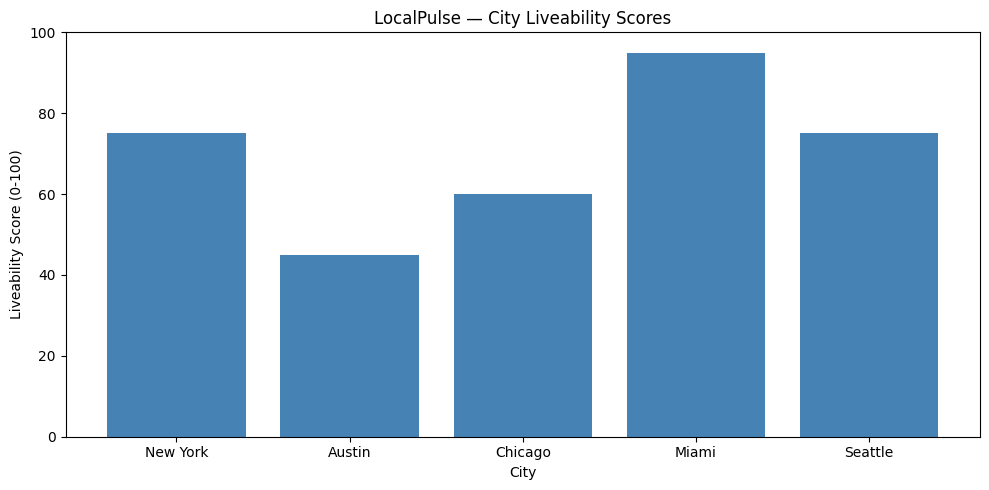

Chart saved!


In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(combined["city"], combined["liveability_score"], color="steelblue")
plt.title("LocalPulse — City Liveability Scores")
plt.xlabel("City")
plt.ylabel("Liveability Score (0-100)")
plt.ylim(0, 100)
plt.tight_layout()

# Save to current directory if raw folder not found
os.makedirs("raw", exist_ok=True)
plt.savefig("raw/liveability_chart.png")
plt.show()
print("Chart saved!")